# Central $g_2$ normalized to $|F|^2$

Innermost-ring $g_2$ for the (120) $\rightarrow$ (111) track, rewritten as

$$g_2(t) = 1 + A\,|F(t)|^2 \quad\Rightarrow\quad |F|^2 = (g_2-1)/A$$

$A$ is the fitted contrast. Error bars are $\sigma_{g_2}/A$.

Colors are **turbo** on a locked 320–420 K scale (`temperature_color`). Use that helper on every later temperature plot so the colors stay the same.

In [1]:
import sys
sys.path.append('../src/')

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from scan import resolve_work_path
from postprocess import (
    TRACKED_SCANS,
    discover_results,
    load_peak_g2,
    central_F2,
    g2_two_tau,
    temperature_cmap,
    temperature_color,
    temperature_norm,
)

In [2]:
def apply_paper_style():
    helvetica = font_manager.FontProperties(family='Helvetica')
    font_manager.findfont(helvetica, fallback_to_default=False)
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica', 'Arial'],
        'font.size': 9,
        'axes.labelsize': 11,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 8,
        'legend.frameon': False,
        'axes.linewidth': 1.0,
        'lines.linewidth': 1.2,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.width': 1.0,
        'ytick.major.width': 1.0,
        'xtick.major.size': 4.5,
        'ytick.major.size': 4.5,
        'xtick.top': True,
        'ytick.right': True,
        'mathtext.fontset': 'custom',
        'mathtext.rm': 'Helvetica',
        'mathtext.it': 'Helvetica:italic',
        'mathtext.bf': 'Helvetica:bold',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.03,
    })


apply_paper_style()

cmap = temperature_cmap()   # turbo
norm = temperature_norm()   # 320 → 420 K, do not change on later figures
FIGSIZE = (6.4, 4.6)

print('locked temperature colors')
for T, *_ in TRACKED_SCANS:
    rgba = temperature_color(T, cmap=cmap, norm=norm)
    print(f'  {T:g} K  {rgba}')

locked temperature colors
  320 K  (np.float64(0.18995), np.float64(0.07176), np.float64(0.23217), np.float64(1.0))
  329 K  (np.float64(0.26652), np.float64(0.32768), np.float64(0.76412), np.float64(1.0))
  339 K  (np.float64(0.25862), np.float64(0.57958), np.float64(0.99876), np.float64(1.0))
  350 K  (np.float64(0.0975), np.float64(0.83714), np.float64(0.80342), np.float64(1.0))
  360 K  (np.float64(0.27597), np.float64(0.97092), np.float64(0.51653), np.float64(1.0))
  370 K  (np.float64(0.64362), np.float64(0.98999), np.float64(0.23356), np.float64(1.0))
  380 K  (np.float64(0.88331), np.float64(0.86553), np.float64(0.21719), np.float64(1.0))
  399 K  (np.float64(0.94977), np.float64(0.37729), np.float64(0.07905), np.float64(1.0))
  420 K  (np.float64(0.4796), np.float64(0.01583), np.float64(0.01055), np.float64(1.0))


In [3]:
config_path = Path('../configs/config_B10.json')
config = json.loads(config_path.read_text()) if config_path.exists() else {}

curves = []
for Temperature, Scan, hkl in TRACKED_SCANS:
    work = resolve_work_path('NBH', Scan, Temperature, 20, config=config)
    files = discover_results(work / 'results', reflections=(hkl,))
    data = central_F2(load_peak_g2(files[hkl]))
    curves.append(data)
    print(f"T={data['temperature']:g} K  ({data['reflection']})  A={data['A']:.4f}  ring={data['central_index']}")

T=320 K  (120)  A=0.2438  ring=0
T=329 K  (120)  A=0.1485  ring=0
T=339 K  (120)  A=1.2015  ring=0
T=350 K  (120)  A=0.7572  ring=0
T=360 K  (111)  A=0.2943  ring=0
T=370 K  (111)  A=0.6322  ring=0
T=380 K  (111)  A=0.1135  ring=0
T=399 K  (111)  A=0.3130  ring=0
T=420 K  (111)  A=0.1888  ring=0


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


saved ../figures/g2_central_F2.pdf


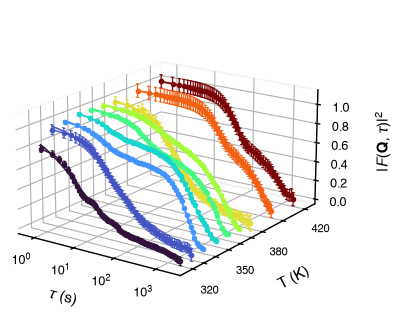

In [14]:
fig = plt.figure(figsize=FIGSIZE)
ax = fig.add_subplot(111, projection='3d')

# Draw 420 K first (now in the back) so 320 K sits in front
for data in sorted(curves, key=lambda d: -d['temperature']):
    T = data['temperature']
    color = temperature_color(T, cmap=cmap, norm=norm)
    t = data['delays']
    z = data['F2']
    e = data['F2_error']
    ok = np.isfinite(t) & np.isfinite(z) & (t > 0)
    x = np.log10(t[ok])
    y = np.full(x.size, T)
    zz = z[ok]
    ee = e[ok]

    popt = data.get('popt')
    if popt is not None:
        p = np.asarray(popt)
        p = p[data['central_index']] if p.ndim == 2 else p
        if np.all(np.isfinite(p)):
            t_line = np.logspace(np.log10(t[ok].min()), np.log10(t[ok].max()), 400)
            ax.plot(
                np.log10(t_line),
                np.full(t_line.size, T),
                (g2_two_tau(t_line, *p) - 1.0) / data['A'],
                color=color, lw=1.15,
            )

    ax.plot(x, y, zz, color=color, lw=1.0)
    ax.scatter(x, y, zz, color=color, s=9, depthshade=False, zorder=5)
    # 339–370 K have small |F|^2 errors (large A); caps keep them visible
    cap = 0.035
    for xi, yi, zi, ei in zip(x, y, zz, ee):
        ax.plot([xi, xi], [yi, yi], [zi - ei, zi + ei], color=color, lw=0.9)
        ax.plot([xi - cap, xi + cap], [yi, yi], [zi - ei, zi - ei], color=color, lw=0.7)
        ax.plot([xi - cap, xi + cap], [yi, yi], [zi + ei, zi + ei], color=color, lw=0.7)

ax.set_xlabel(r'$\tau$ (s)', labelpad=6)
ax.set_ylabel('T (K)', labelpad=10)
ax.set_ylim(310, 430)   # 320 K in front, 420 K recedes
ax.set_zlim(-0.05, 1.15)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels([r'$10^{0}$', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])
temps = [T for T, *_ in TRACKED_SCANS]
# Keep a tick at every T, but only label a spaced subset so they stay readable
label_T = {320, 350, 380, 420}
ax.set_yticks(temps)
ax.set_yticklabels([f'{T:g}' if T in label_T else '' for T in temps])
ax.view_init(elev=18, azim=-55)
ax.set_box_aspect((1.35, 1.7, 0.85))
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.tick_params(axis='x', pad=2)
ax.tick_params(axis='z', pad=2)
ax.tick_params(axis='y', pad=4, labelsize=8)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r'$|F(\mathbf{Q},\tau)|^2$', labelpad=8, rotation=90)

#cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.08, shrink=0.65, fraction=0.035)
#cbar.set_label('T (K)')
#cbar.set_ticks([T for T, *_ in TRACKED_SCANS])

out = Path('../figures')
out.mkdir(exist_ok=True)
fig.subplots_adjust(left=0.04, right=0.86, bottom=0.08, top=0.96)
fig.savefig(out / 'g2_central_F2.pdf')
fig.savefig(out / 'g2_central_F2.png')
print('saved', out / 'g2_central_F2.pdf')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


saved ../figures/g2_central_F2_offset.pdf


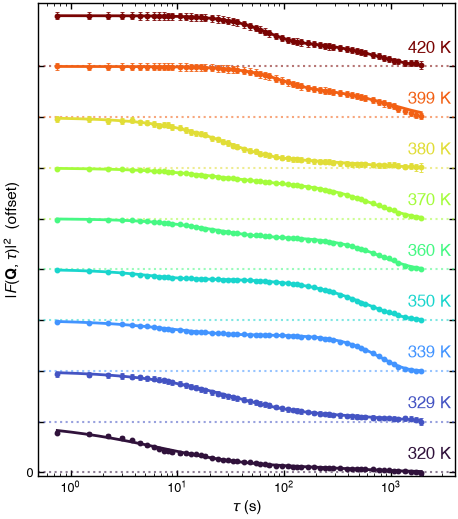

In [38]:
# 2D waterfall: |F|^2 vs tau, offset vertically by temperature
OFFSET = 1.0
by_T = sorted(curves, key=lambda d: d['temperature'])

fig, ax = plt.subplots(figsize=(4.8, 5.4))
for i, data in enumerate(by_T):
    T = data['temperature']
    color = temperature_color(T, cmap=cmap, norm=norm)
    lift = i * OFFSET
    t = data['delays']
    y = data['F2']
    e = data['F2_error']
    ok = np.isfinite(t) & np.isfinite(y) & (t > 0)

    ax.axhline(lift, color=color, ls=':', lw=1.5, alpha=0.55)
    ax.errorbar(
        t[ok], y[ok] + lift, yerr=e[ok],
        fmt='o', color=color, ecolor=color, elinewidth=0.6,
        capsize=1.5, capthick=0.6, markersize=3.2, zorder=3,
    )
    popt = data.get('popt')
    if popt is not None:
        p = np.asarray(popt)
        p = p[data['central_index']] if p.ndim == 2 else p
        if np.all(np.isfinite(p)):
            t_line = np.logspace(np.log10(t[ok].min()), np.log10(t[ok].max()), 400)
            ax.plot(t_line, (g2_two_tau(t_line, *p) - 1.0) / data['A'] + lift,
                    color=color, lw=2.0, zorder=4)
    ax.text(t[ok].max() * 0.75, lift + 0.21, f'{T:g} K', color=color,
            fontsize=12, va='bottom', ha='left')

ax.set_xscale('log')
ax.set_xlabel(r'$\tau$ (s)')
ax.set_ylabel(r'$|F(\mathbf{Q},\tau)|^2$  (offset)')
ax.set_xlim(0.5, 4e3)
ax.set_ylim(-0.08, (len(by_T) - 1) * OFFSET + 1.25)
ax.set_yticks([i * OFFSET for i in range(len(by_T))])
ax.set_yticklabels(['0'] + [''] * (len(by_T) - 1))

out = Path('../figures')
out.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(out / 'g2_central_F2_offset.pdf')
fig.savefig(out / 'g2_central_F2_offset.png')
print('saved', out / 'g2_central_F2_offset.pdf')